In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.model_selection import train_test_split

from rapidgbm import RapidGBMTuner

import glob
import mplhep as hep
hep.style.use([hep.style.ATLAS])
import pickle

In [2]:
def unpair_df(data):
    """
    Unpairs columns in the DataFrame that start with 'l1' or 'l2' by renaming them to 'l'
    and concatenating the resulting DataFrames vertically.

    Parameters:
    data (pd.DataFrame): The original DataFrame containing columns to be unpaired.

    Returns:
    pd.DataFrame: A new DataFrame with columns starting with 'l1' and 'l2' renamed to 'l',
                  and the DataFrame length doubled by concatenating the modified DataFrames.
    """
    l1_columns = [col for col in data.columns if 'l1' in col]
    l2_columns = [col for col in data.columns if 'l2' in col]
    other_columns = [col for col in data.columns if not ('l1' in col or 'l2' in col)]

    # Create a copy of the DataFrame with 'l1' and 'l2' columns renamed to 'l'
    data_l1 = data[other_columns + l1_columns].copy()
    data_l2 = data[other_columns + l2_columns].copy()

    data_l1.rename(columns={col: col.replace('l1', 'm_lx', 1) for col in l1_columns}, inplace=True)
    data_l2.rename(columns={col: col.replace('l2', 'm_lx', 1) for col in l2_columns}, inplace=True)

    # Concatenate the DataFrames vertically
    new_data = pd.concat([data_l1, data_l2], ignore_index=True)
    return new_data

def repair_df(data):
    """
    Pairs columns in the DataFrame that contain 'm_lx' by renaming them back to 'l1' and 'l2',
    and merges rows based on shared columns, resulting in the original DataFrame format.

    Parameters:
    data (pd.DataFrame): The DataFrame output from `unpair_df` function with doubled rows.

    Returns:
    pd.DataFrame: A DataFrame where columns containing 'm_lx' are renamed back to 'l1' and 'l2',
                  and rows are merged back to their original format with shared columns appearing only once.
    """
    # Split the data into two halves
    midpoint = len(data) // 2
    data_l1 = data.iloc[:midpoint].copy()
    data_l2 = data.iloc[midpoint:].copy()

    # Identify shared columns (not containing 'm_lx')
    shared_columns = [col for col in data.columns if 'm_lx' not in col]

    # Rename columns by replacing 'm_lx' with 'l1' in data_l1 and 'l2' in data_l2
    data_l1.rename(columns={col: col.replace('m_lx', 'l1') for col in data_l1.columns if 'm_lx' in col}, inplace=True)
    data_l2.rename(columns={col: col.replace('m_lx', 'l2') for col in data_l2.columns if 'm_lx' in col}, inplace=True)

    # Concatenate the two halves on columns, only including shared columns once
    paired_data = pd.concat(
        [data_l1.reset_index(drop=True)[shared_columns + [col for col in data_l1.columns if col not in shared_columns]],
         data_l2.reset_index(drop=True)[[col for col in data_l2.columns if col not in shared_columns]]],
        axis=1
    )

    return paired_data

def filter_columns(df, key_phrases):
    """
    Filters out columns that contain any of the key phrases in their names.

    Parameters:
    df (pd.DataFrame): The dataframe to filter.
    key_phrases (list): A list of key phrases to filter out.

    Returns:
    list: A list of column names that do not contain any of the key phrases.
    """
    filtered_columns = [col for col in df.columns if not any(phrase in col for phrase in key_phrases)]
    return filtered_columns


In [3]:
data_ttbar = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_root/ttbar_arnau_config_200k.parquet')
data_zee = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_root/zee_deriv_arnau_config_200k.parquet')

no


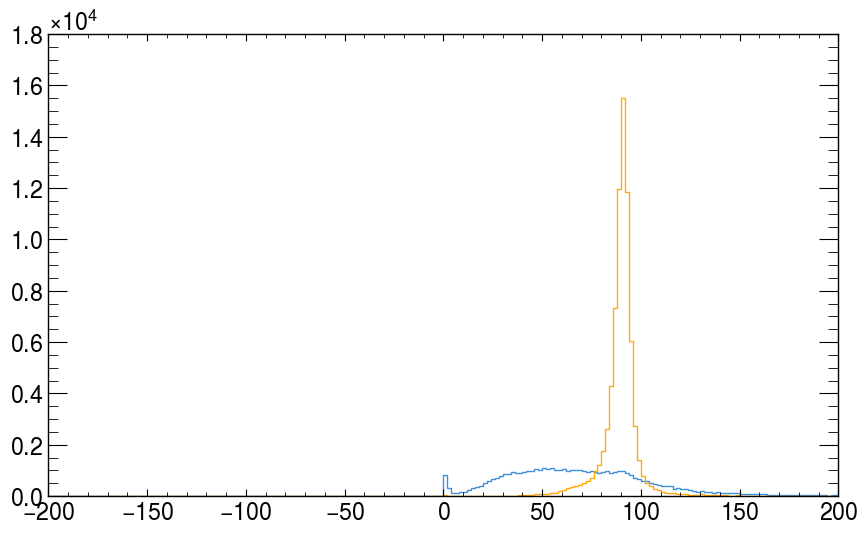

In [4]:
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(data_ttbar['ll_m'], bins=200, range=(-200,200), histtype='step', label='ttbar', density=False)
ax.hist(data_zee['ll_m'], bins=200, range=(-200,200), histtype='step', label='zee', density=False)

print('no')

In [5]:
# from z truth boolean:

from_z_bool = (data_zee['l1_truthOrigin'] == 13) & (data_zee['l2_truthOrigin'] == 13) & (data_zee['l1_truthPdgId'] * data_zee['l2_truthPdgId'] == -121)
print(from_z_bool.sum()/len(from_z_bool))

data_zee['truth_from_Z'] = from_z_bool

from_z_bool = (data_ttbar['l1_truthOrigin'] == 13) & (data_ttbar['l2_truthOrigin'] == 13) & (data_ttbar['l1_truthPdgId'] * data_ttbar['l2_truthPdgId'] == -121)
print(from_z_bool.sum()/len(from_z_bool))

data_ttbar['truth_from_Z'] = from_z_bool

0.9528303118106948
0.0


In [6]:
bad_events = (data_zee['ll_m_Truth'] < 10) | (data_zee['ll_m_Truth'] > 200)
print(data_zee['l1_BadCSC'][bad_events].value_counts())


print(f'number of bad events from zee: {bad_events.sum()}, good events: {(~bad_events).sum()}, {bad_events.sum()/len(data_zee)}')

data_zee = data_zee[~bad_events]

print(data_zee['truth_from_Z'].sum()/len(data_zee))

bad_events = (data_ttbar['ll_m_Truth'] < 10) | (data_ttbar['ll_m_Truth'] > 200)

print(f'number of bad events from ttbar: {bad_events.sum()}, {bad_events.sum()/len(data_ttbar)}')

data_ttbar = data_ttbar[~bad_events]

l1_BadCSC
False    36876
Name: count, dtype: int64
number of bad events from zee: 36876, good events: 39741, 0.4813031050550139
0.9561158501295891
number of bad events from ttbar: 37492, 0.7653615318662474


In [7]:
print(data_zee['l1_truthType'][data_zee['truth_from_Z']].value_counts())
print(data_zee['l2_truthType'][data_zee['truth_from_Z']].value_counts())

l1_truthType
2.0    37997
Name: count, dtype: int64
l2_truthType
2.0    37997
Name: count, dtype: int64


In [8]:
print(np.min(data_zee['ll_m_Truth'][data_zee['truth_from_Z']]))

10.748244285583496


no


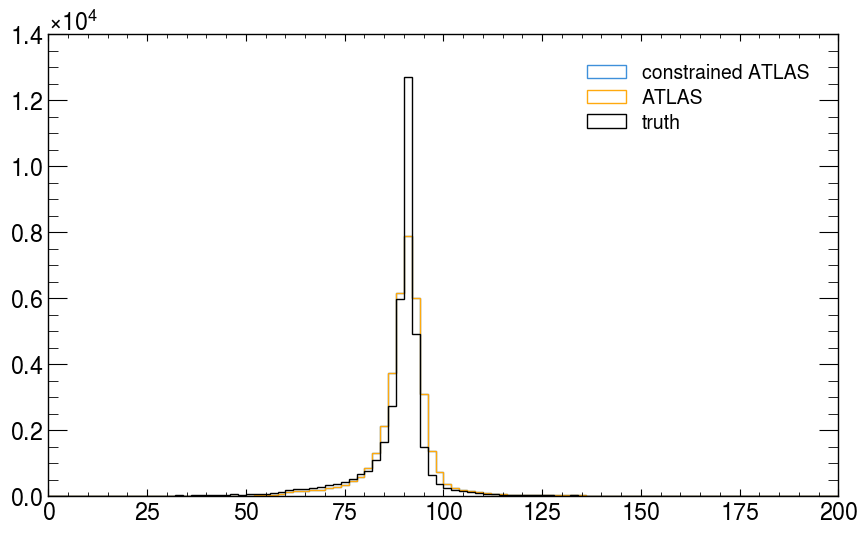

In [9]:
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(data_zee['ll_m_Zmassconstraint'][data_zee['truth_from_Z']], bins=100, range=(0,200), histtype='step', label='constrained ATLAS', density=False)
ax.hist(data_zee['ll_m'][data_zee['truth_from_Z']], bins=100, range=(0,200), histtype='step', label='ATLAS', density=False)
ax.hist(data_zee['ll_m_Truth'][data_zee['truth_from_Z']], bins=100, range=(0,200), histtype='step', label='truth', density=False,color='black')

ax.legend()
print('no')

In [10]:
for i in range(len(data_zee.columns)):
    print(data_zee.columns[i])

Btag60_N_j
Btag70_N_j
Btag77_N_j
Btag85_N_j
Btag_N_j
Central_N_j
Central_pT_jj
EventInfo.PVx
EventInfo.PVy
EventInfo.PVz
EventInfo.actualIntPerXing
EventInfo.averageIntPerXing
EventInfo.mu
MET_Dphi_ForwardJets
MET_Dphi_SoftJets
MET_Dphi_Zy
MET_Dphi_j1
MET_Dphi_l1
MET_Dphi_l2
MET_Dphi_ll
MET_Dphi_ph
MET_RefEle
MET_RefGamma
MET_RefJets
MET_RefMuons
MET_met_PVSoftTrk
MET_met_SoftClus
MET_met_TST
MET_met_Truth
MET_phi_PVSoftTrk
MET_phi_TST
MET_sig_TST
MET_sig_Truth
MET_sumet_TST
MET_sumet_Truth
MET_x_TST
MET_y_TST
ML_l1_eta
ML_l1_m
ML_l1_phi
ML_l1_pt
ML_l2_eta
ML_l2_m
ML_l2_phi
ML_l2_pt
ML_l3_eta
ML_l3_m
ML_l3_phi
ML_l3_pt
ML_l4_eta
ML_l4_m
ML_l4_phi
ML_l4_pt
VBF_BDTG
VBF_DRmin_y_j
VBF_Dphi_Zy_jj
VBF_Dphi_Zy_jj_FullRange
VBF_Dy_j_j
VBF_N_j
VBF_Zepp
VBF_eta_j1
VBF_eta_j2
VBF_m_jj
VBF_mass_j1
VBF_mass_j2
VBF_pT_j1
VBF_pT_j2
VBF_pT_jj
VBF_pTt_Zy
VBF_passFJVT_j1
VBF_passFJVT_j2
VBF_phi_j1
VBF_phi_j2
Z_truth_mass
Zy_Dphi_j1
etaTruthL0
etaTruthL1
etaTruthY
j1_eta_Truth
j1_m_Truth
j1_phi_Truth
j1

In [11]:
data_zee_truth = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_root/zee_deriv_arnau_config_200k_truth.parquet')
for i in range(len(data_zee_truth.columns)):
    print(data_zee_truth.columns[i])

m_eventNumber
m_mc_channel_number
higgs_truth_pt
higgs_truth_eta
higgs_truth_phi
higgs_truth_mass
l1_truth_pt
l1_truth_eta
l1_truth_phi
l1_truth_mass
l1_truth_pdgId
l2_truth_pt
l2_truth_eta
l2_truth_phi
l2_truth_mass
l2_truth_pdgId
ph_truth_pt
ph_truth_eta
ph_truth_phi
ph_truth_mass
Z_truth_pt
Z_truth_eta
Z_truth_phi
Z_truth_mass
Dphi_Zy_jj
pTt
dphi_Zy
eta_Zepp
m_jj
DRmin_Z_j
Dy_j_j
BDTG
N_jets
Central_N_jets
j1_truth_pt
j2_truth_pt


In [12]:
mass = np.sqrt(2 * data_zee_truth['l1_truth_pt'] * data_zee_truth['l2_truth_pt'] *
                (np.cosh(data_zee_truth['l1_truth_eta'] - data_zee_truth['l2_truth_eta']) 
                 - np.cos(data_zee_truth['l1_truth_phi'] - data_zee_truth['l2_truth_phi'])))

In [13]:
signal = data_zee[data_zee['truth_from_Z']]
background = data_ttbar
print(f'total signal: {len(signal)}, total background: {len(background)}')

signal = signal.sample(n=len(background), replace=False, random_state=42)

data = pd.concat([background, signal], ignore_index=True)
unpaired_data = unpair_df(data)

key_phrases = ['truth', 'ph', 'Truth', 'mc']
param_list_unpair = filter_columns(unpaired_data, key_phrases)

total signal: 37997, total background: 11494


In [14]:
# old parm list
iso_param_list_old = ['el1_ptvarcone20', 'el1_topoetcone20', 'el1_topoetcone40', 'el1_ptvarcone30_Nonprompt_All_MaxWeightTTVALooseCone_pt1000',
               'el1_ptcone20_Nonprompt_All_MaxWeightTTVALooseCone_pt1000', 'el1_core57cellsEnergyCorrection',
               'el1_topoetcone20ptCorrection', 'el1_ptcone20_Nonprompt_All_MaxWeightTTVALooseCone_pt500',
               'el1_ptvarcone30_Nonprompt_All_MaxWeightTTVALooseCone_pt500']
iso_param_list_new = ['m_lx_ptcone20', 'm_lx_ptcone20_pt1000', 'm_lx_ptcone20_pt500', 'm_lx_ptcone30',
                  'm_lx_ptvarcone20', 'm_lx_ptvarcone30', 'm_lx_ptvarcone30_pt1000', 'm_lx_ptvarcone30_pt500',
                  'm_lx_topoetcone20', 'm_lx_topoetcone20ptCorrection', 'm_lx_topoetcone40']


In [15]:
# iso model
# target = l_truthType == 2

isotarget = unpaired_data['m_lx_truthType'] == 2

In [16]:
print((unpaired_data['EventInfo.eventNumber']%4).value_counts())

EventInfo.eventNumber
0    11564
2    11556
3    11494
1    11362
Name: count, dtype: int64


In [17]:
iso_predictions = np.zeros(len(isotarget))
retrain_iso = False
if retrain_iso:
    for i in range(4):
        X_train = unpaired_data[iso_param_list_new][unpaired_data['EventInfo.eventNumber']%4 != i]
        y_train = isotarget[unpaired_data['EventInfo.eventNumber']%4 != i]
        X_test = unpaired_data[iso_param_list_new][unpaired_data['EventInfo.eventNumber']%4 == i]
        y_test = isotarget[unpaired_data['EventInfo.eventNumber']%4 == i]

        tuner = RapidGBMTuner(metric='auc', trials=100, refit=True, verbosity=1, visualization=True, seed=414243)#, grid='h,learning_rate')

        tuner.fit(X_train, y_train)
        iso_predictions[unpaired_data['EventInfo.eventNumber']%4 == i] = tuner.predict_proba(X_test)

        with open(f'iso_tuner_{i}.pkl', 'wb') as f:
            pickle.dump(tuner, f)
else:
    for i in range(4):
        with open(f'iso_tuner_{i}.pkl', 'rb') as f:
            tuner = pickle.load(f)
            iso_predictions[unpaired_data['EventInfo.eventNumber']%4 == i] = tuner.predict_proba(unpaired_data[iso_param_list_new][unpaired_data['EventInfo.eventNumber']%4 == i])

In [18]:
plt.rcdefaults()
hep.style.use([hep.style.ATLAS])


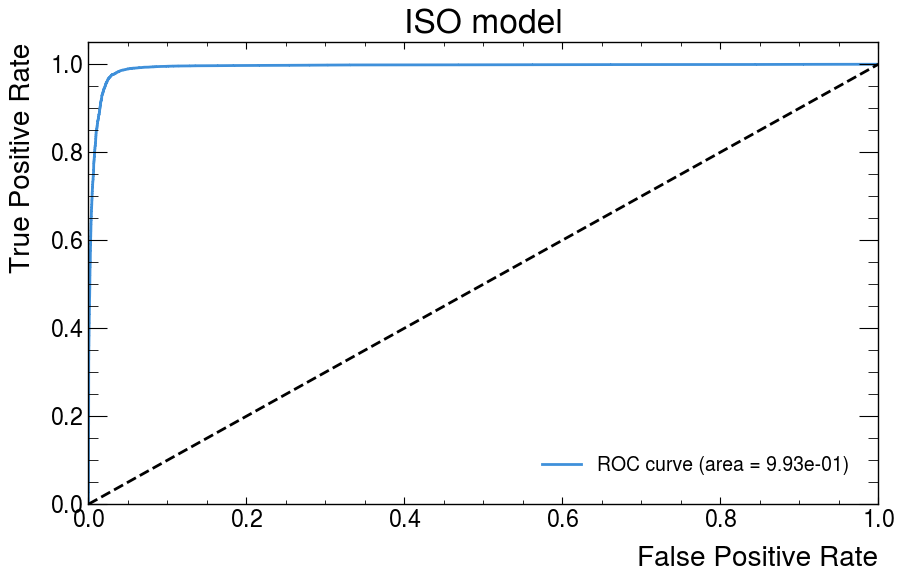

In [19]:
## roc curve
y_pred = iso_predictions
fpr, tpr, thresholds = roc_curve(isotarget, y_pred)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2e})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ISO model')
ax.legend(loc='lower right')


In [20]:
print(unpaired_data['EventInfo.eventNumber'].iloc[0])
print(len(unpaired_data)/2)
print(np.where(unpaired_data['EventInfo.eventNumber'] == unpaired_data['EventInfo.eventNumber'].iloc[0]))

12520001
22988.0
(array([    0, 22988]),)


In [21]:
unpaired_data['m_lx_iso_predictions'] = iso_predictions
repaired_data = repair_df(unpaired_data)

In [22]:
# now we train an identification model

target = repaired_data['truth_from_Z']
print(sum(target)/len(target))

0.5


In [23]:
pred_z_param_list = ['l1_iso_predictions', 'l2_iso_predictions', 
                     'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0',]




 * Initiating LGBMTuner.fit
     . Settings:
     .. Trying 100 trials
     .. Evaluation metric: auc 
     .. Study direction: minimize log_loss

     . Trial number: 0 finished
     .. Optimization score (lower-better): log_loss: 0.1918140342176937
     .. Evaluation score (greater-better): auc: 0.9543003385528336
 ...........................................................................
     . Trial number: 1 finished
     .. Optimization score (lower-better): log_loss: 0.17489161472872553
     .. Evaluation score (greater-better): auc: 0.9607530293389401
 ...........................................................................
     . Trial number: 2 finished
     .. Optimization score (lower-better): log_loss: 0.18199625824219556
     .. Evaluation score (greater-better): auc: 0.9606471235112666
 ...........................................................................
     . Trial number: 3 finished
     .. Optimization score (lower-better): log_loss: 0.19093568234542566
 

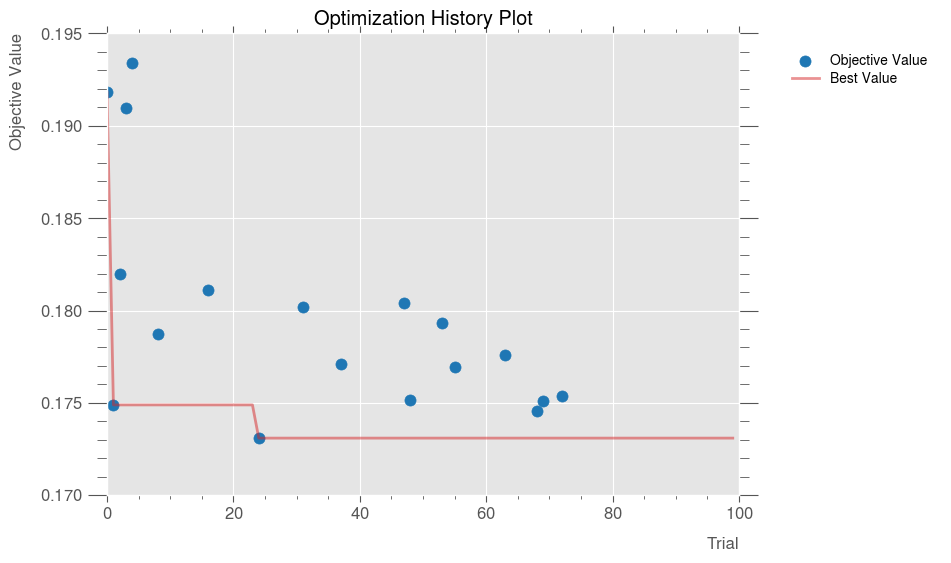

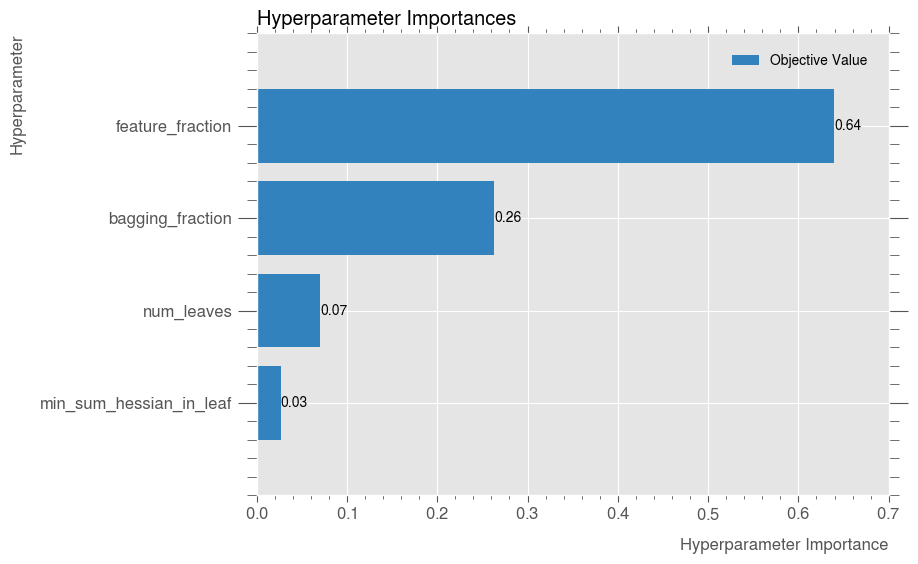

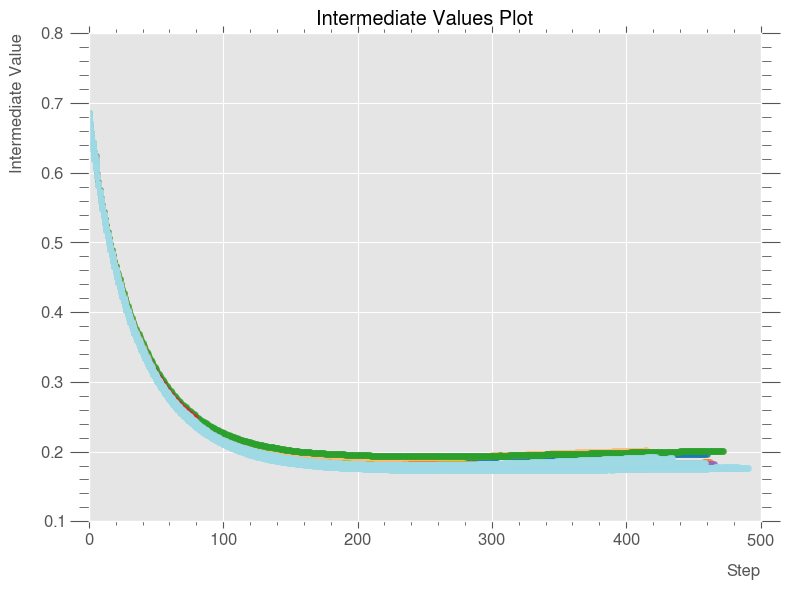

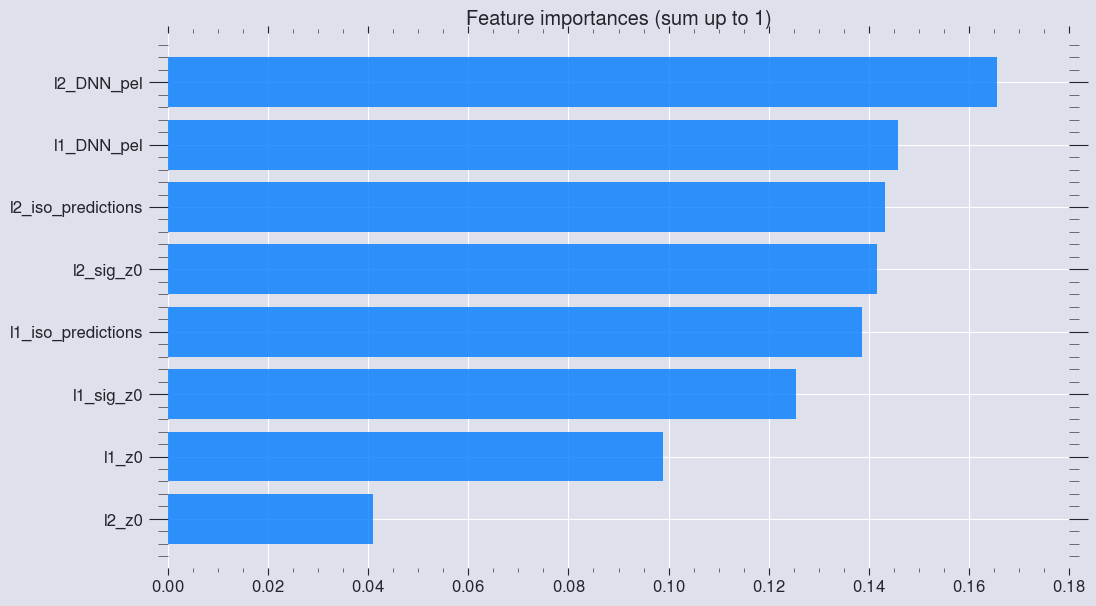


     . Optuna hyperparameters optimization finished
     .. Best trial number:24    |     log_loss:          0.17309455368473461
 ---------------------------------------------------------------------------

Time elapsed for fit execution: 37.09066 seconds

 * Initiating LGBMTuner.fit
     . Settings:
     .. Trying 100 trials
     .. Evaluation metric: auc 
     .. Study direction: minimize log_loss

     . Trial number: 0 finished
     .. Optimization score (lower-better): log_loss: 0.19276650321131575
     .. Evaluation score (greater-better): auc: 0.9544363785993459
 ...........................................................................
     . Trial number: 1 finished
     .. Optimization score (lower-better): log_loss: 0.18984992874010173
     .. Evaluation score (greater-better): auc: 0.9580313982569056
 ...........................................................................
     . Trial number: 2 finished
     .. Optimization score (lower-better): log_loss: 0.1852537100

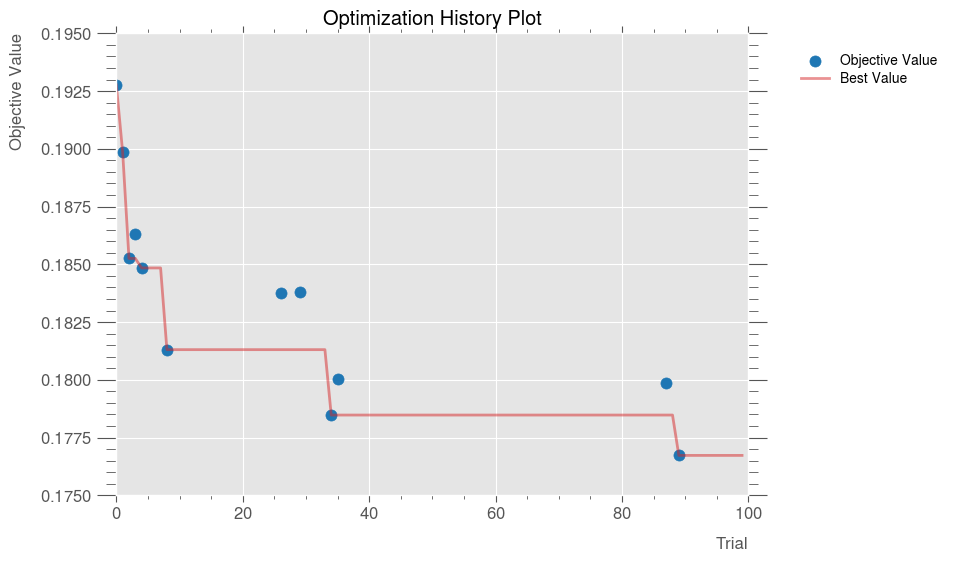

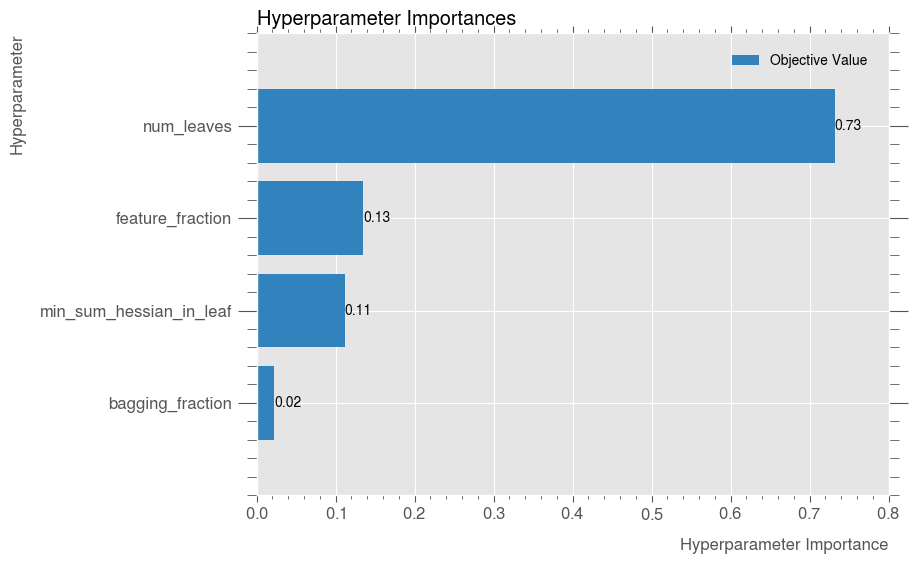

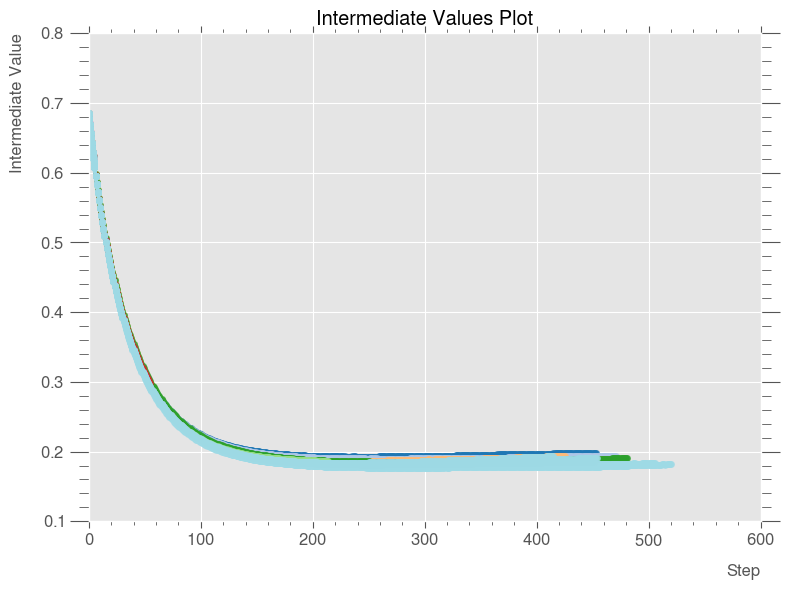

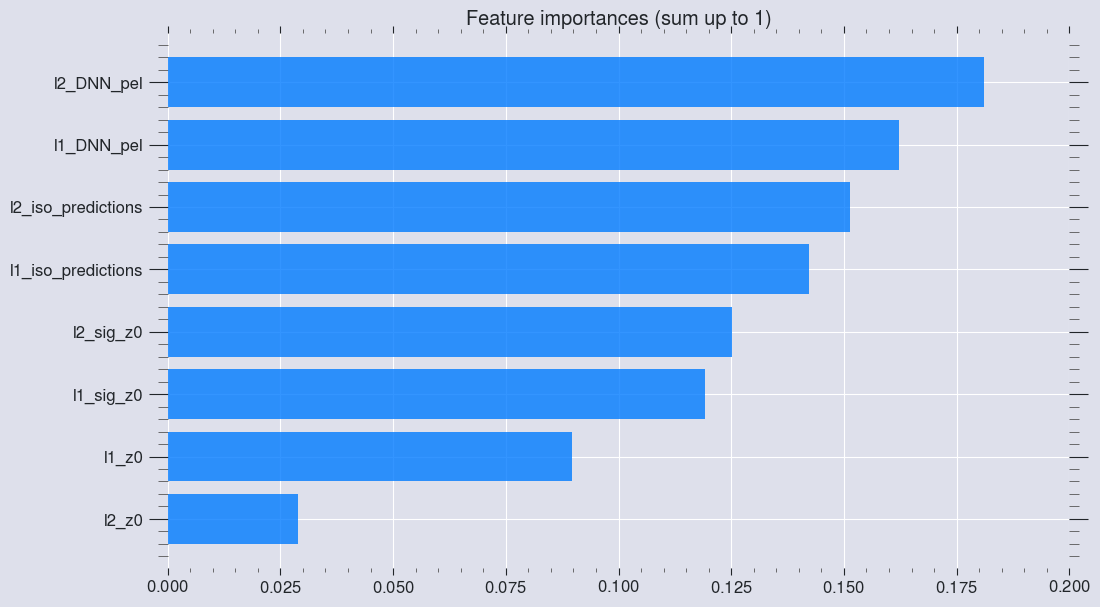


     . Optuna hyperparameters optimization finished
     .. Best trial number:89    |     log_loss:          0.17672724244183585
 ---------------------------------------------------------------------------

Time elapsed for fit execution: 23.64199 seconds

 * Initiating LGBMTuner.fit
     . Settings:
     .. Trying 100 trials
     .. Evaluation metric: auc 
     .. Study direction: minimize log_loss

     . Trial number: 0 finished
     .. Optimization score (lower-better): log_loss: 0.18967427484117041
     .. Evaluation score (greater-better): auc: 0.9575210123248109
 ...........................................................................
     . Trial number: 1 finished
     .. Optimization score (lower-better): log_loss: 0.20028773884051948
     .. Evaluation score (greater-better): auc: 0.9526727953694246
 ...........................................................................
     . Trial number: 2 finished
     .. Optimization score (lower-better): log_loss: 0.1997941662

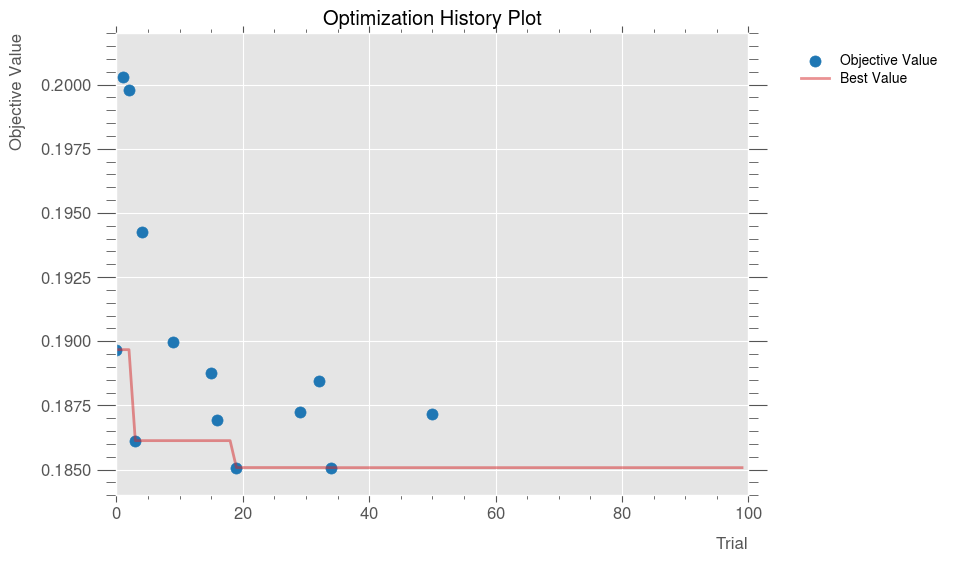

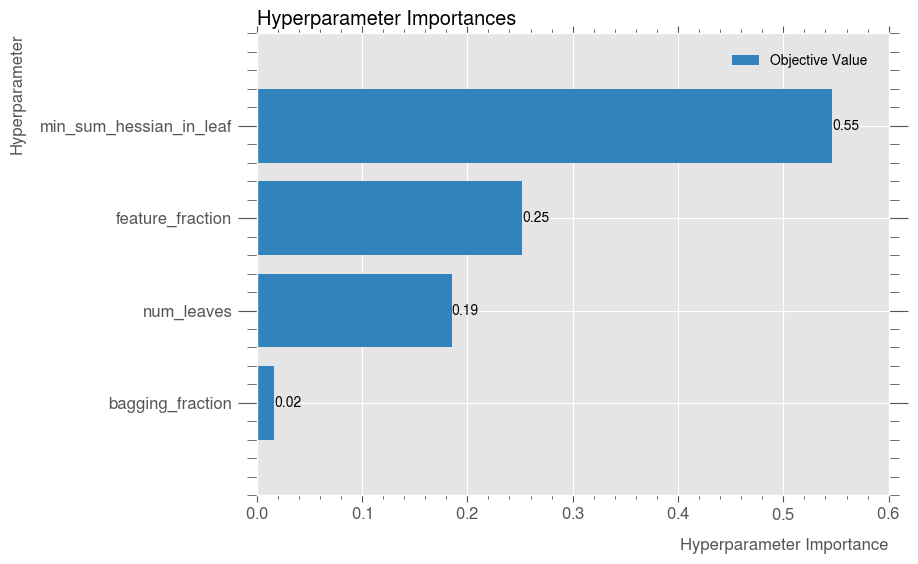

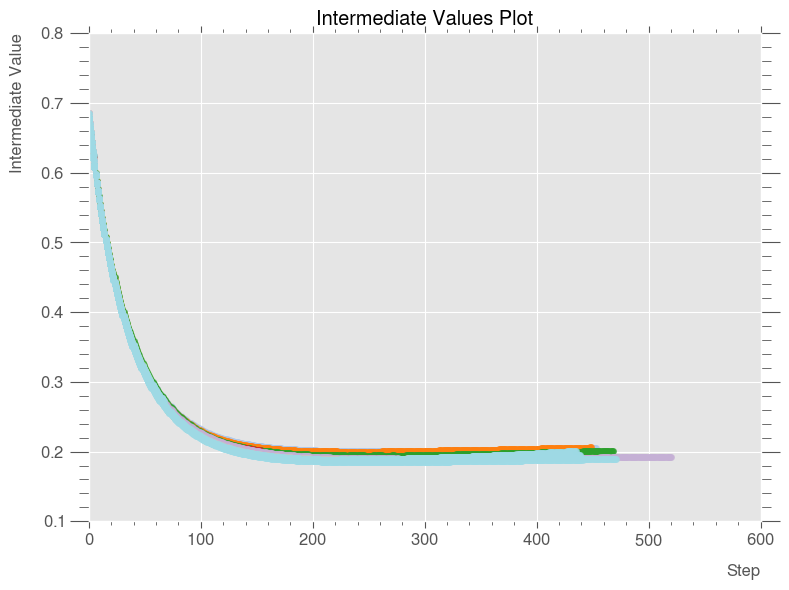

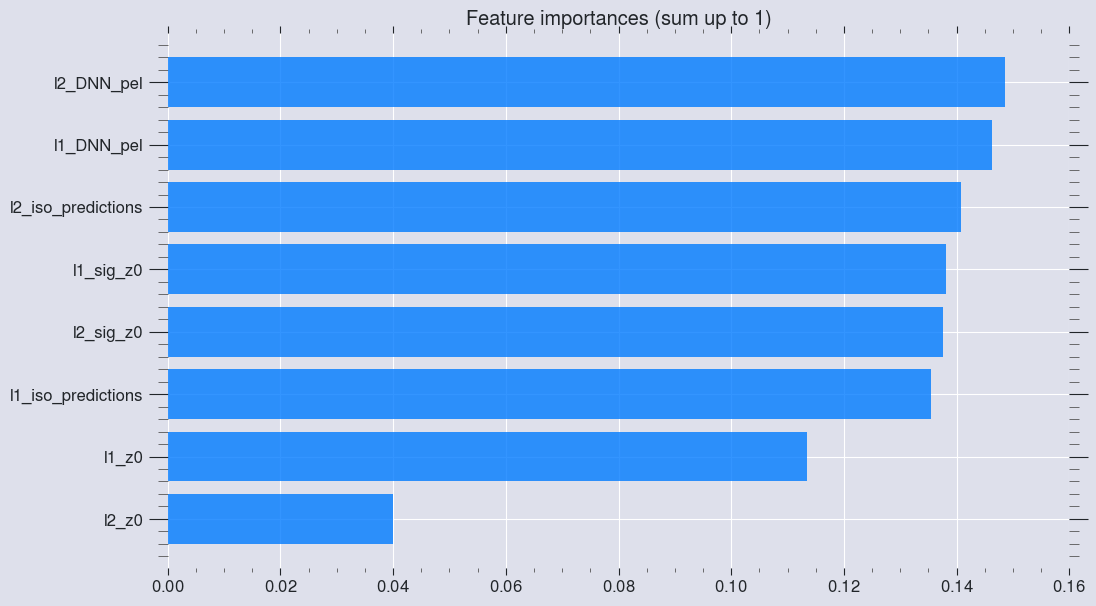


     . Optuna hyperparameters optimization finished
     .. Best trial number:34    |     log_loss:          0.18507764743222266
 ---------------------------------------------------------------------------

Time elapsed for fit execution: 31.81064 seconds

 * Initiating LGBMTuner.fit
     . Settings:
     .. Trying 100 trials
     .. Evaluation metric: auc 
     .. Study direction: minimize log_loss

     . Trial number: 0 finished
     .. Optimization score (lower-better): log_loss: 0.19875462174547356
     .. Evaluation score (greater-better): auc: 0.9537011646948014
 ...........................................................................
     . Trial number: 1 finished
     .. Optimization score (lower-better): log_loss: 0.18756602639149278
     .. Evaluation score (greater-better): auc: 0.954204928773506
 ...........................................................................
     . Trial number: 2 finished
     .. Optimization score (lower-better): log_loss: 0.19236152642

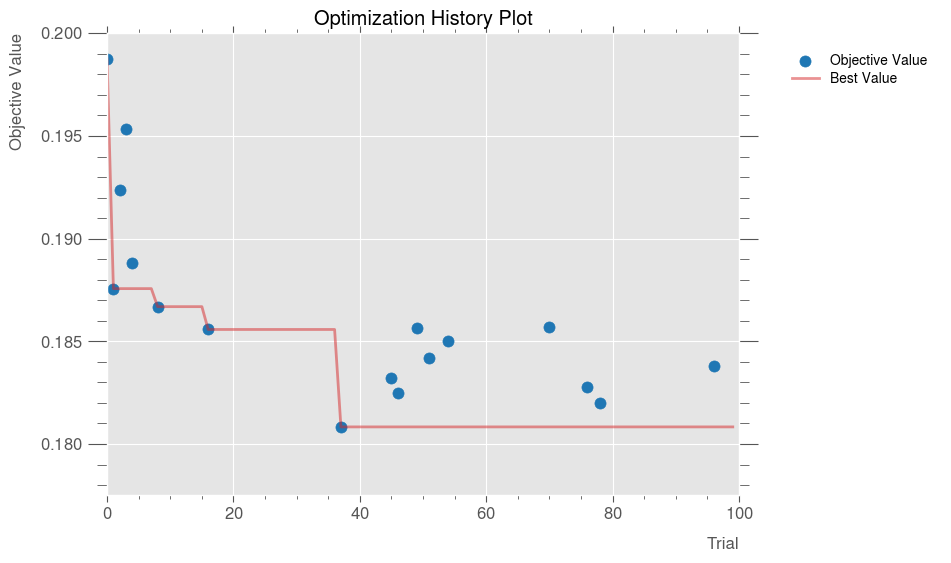

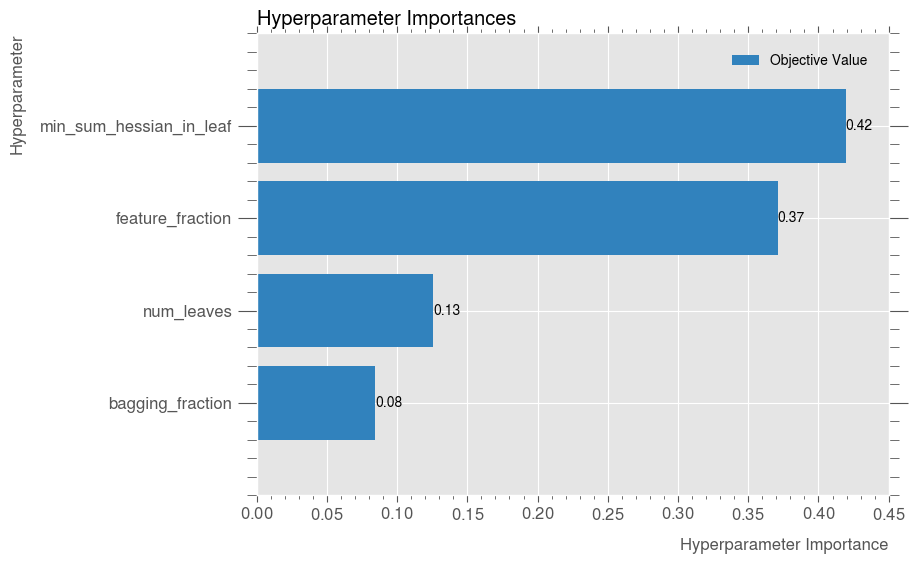

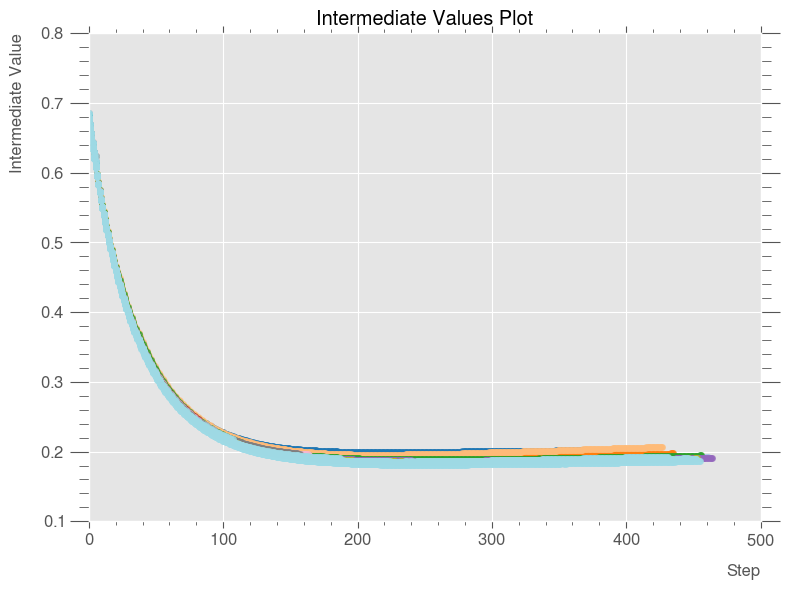

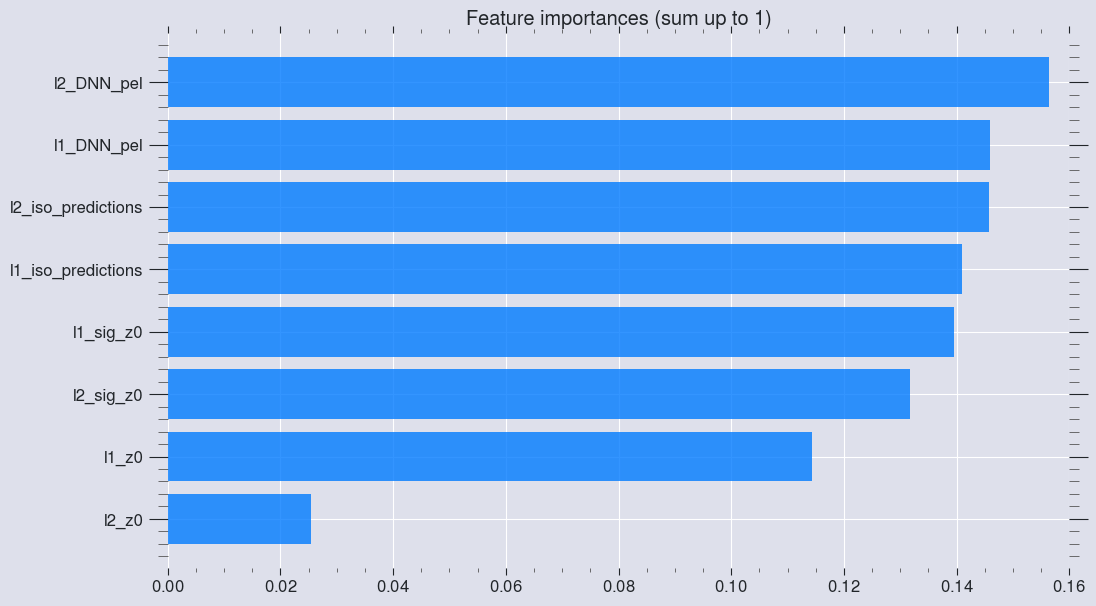


     . Optuna hyperparameters optimization finished
     .. Best trial number:37    |     log_loss:            0.180831647833717
 ---------------------------------------------------------------------------

Time elapsed for fit execution: 35.2967 seconds


In [24]:
retrain_id = True
id_predictions = np.zeros(len(target))
if retrain_id == True:
    for i in range(4):
        X_train = repaired_data[pred_z_param_list][repaired_data['EventInfo.eventNumber']%4 != i]
        y_train = target[repaired_data['EventInfo.eventNumber']%4 != i]
        
        X_test = repaired_data[pred_z_param_list][repaired_data['EventInfo.eventNumber']%4 == i]
        y_test = target[repaired_data['EventInfo.eventNumber']%4 == i]

        tuner = RapidGBMTuner(metric='auc', trials=100, refit=True, verbosity=1, visualization=True, seed=414243)#, grid='h,learning_rate')

        tuner.fit(X_train, y_train)
        id_predictions[repaired_data['EventInfo.eventNumber']%4 == i] = tuner.predict_proba(X_test)

        with open(f'id_tuner_{i}.pkl', 'wb') as f:
            pickle.dump(tuner, f)
else:
    for i in range(4):
        with open(f'id_tuner_{i}.pkl', 'rb') as f:
            tuner = pickle.load(f)
            id_predictions[repaired_data['EventInfo.eventNumber']%4 == i] = tuner.predict_proba(repaired_data[pred_z_param_list][repaired_data['EventInfo.eventNumber']%4 == i])

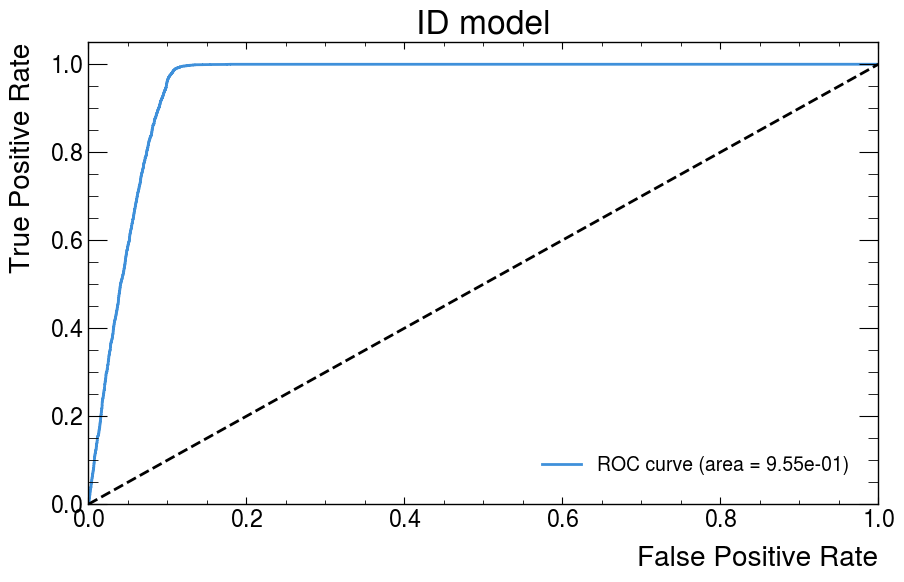

In [25]:
plt.rcdefaults()
hep.style.use([hep.style.ATLAS])

# roc curve
y_pred = id_predictions
fpr, tpr, thresholds = roc_curve(target, y_pred)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2e})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ID model')
ax.legend(loc='lower right')

In [26]:
false_positive_ATLAS = np.sum((repaired_data['EventInfo.cutflow'] >= 14) & (repaired_data['truth_from_Z'] == 0))
print(false_positive_ATLAS)

tuned_cut = np.sort(y_pred[repaired_data['truth_from_Z']==0])[::-1][false_positive_ATLAS]
print(tuned_cut)
print(np.sum(y_pred > tuned_cut))

3198
0.005240438285573309
14651


In [27]:
print(f'signal to background ratio ID: {np.sum(target)/len(target)}')
print(f'signal to background ratio ISO: {np.sum(isotarget)/len(isotarget)}')

signal to background ratio ID: 0.5
signal to background ratio ISO: 0.6486210196624326


Text(0.5, 1.0, 'ATLAS')

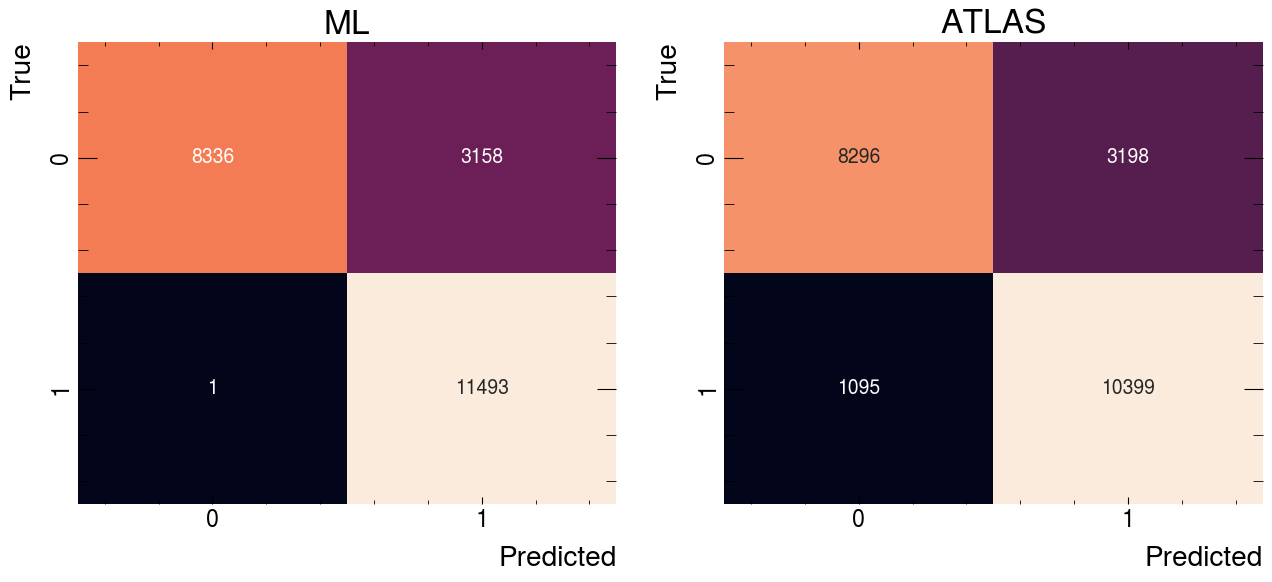

In [28]:
model_predictions = y_pred > tuned_cut

# confusion matrix:
cm = confusion_matrix(target, model_predictions)

fig, ax = plt.subplots(1,2,figsize=(15,6))
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cbar=False)
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')
ax[0].set_title('ML')

cm = confusion_matrix(repaired_data['truth_from_Z'], repaired_data['EventInfo.cutflow'] >= 14)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[1], cbar=False)
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')
ax[1].set_title('ATLAS')


In [29]:
gain_mask = model_predictions & target & (repaired_data['EventInfo.cutflow'] < 14)
print(gain_mask.sum())
print(repaired_data['EventInfo.cutflow'][gain_mask].value_counts())
print(repaired_data['EventInfo.cutflow_new'][gain_mask].value_counts())
print(repaired_data['EventInfo.cutflow'].value_counts())

1094
EventInfo.cutflow
10    1094
Name: count, dtype: int64
EventInfo.cutflow_new
16    1057
17      15
19       9
18       8
15       5
Name: count, dtype: int64
EventInfo.cutflow
14    13173
10     9391
17      256
18      100
19       59
15        9
Name: count, dtype: int64


no


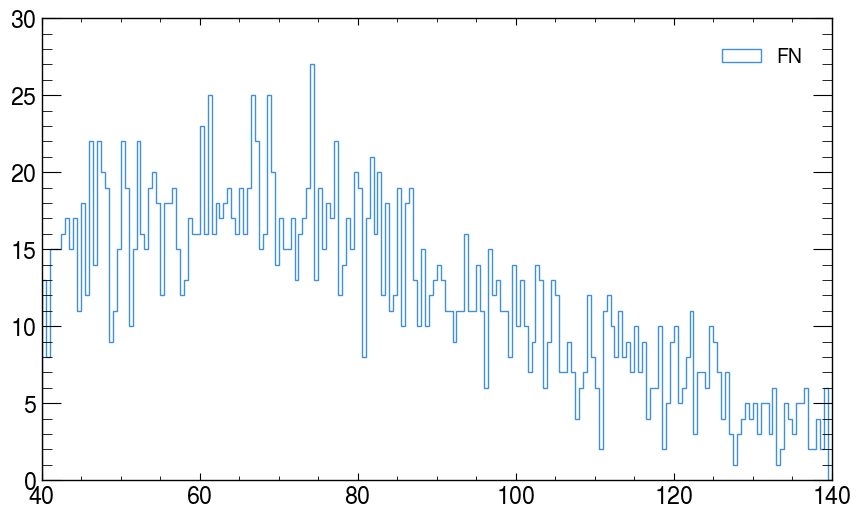

In [30]:
fig, ax = plt.subplots(figsize=(10,6))
# ax.hist(repaired_data['ll_m'], bins=200, range=(40,140), histtype='step', label='ALL', density=False)
# ax.hist(repaired_data['ll_m'][gain_mask], bins=200, range=(40,140), histtype='step', label='GAIN', density=False)
# ax.hist(repaired_data['ll_m'][repaired_data['truth_from_Z']], bins=200, range=(40,140), histtype='step', label='Z', density=False)
# ax.hist(repaired_data['ll_m'][(repaired_data['EventInfo.cutflow'] >= 14) & repaired_data['truth_from_Z']], bins=200, range=(40,140), histtype='step', label='ATLAS', density=False)
# ax.hist(repaired_data['ll_m'][model_predictions & repaired_data['truth_from_Z']], bins=200, range=(40,140), histtype='step', label='ML', density=False)
ax.hist(repaired_data['ll_m'][~repaired_data['truth_from_Z'] & model_predictions], bins=200, range=(40,140), histtype='step', label='FN', density=False)
# ax.set_yscale('log')
ax.legend()
print('no')

3217328
1297247
4280273
1541772
4644468
3104288
2120507
3120559
4905001
28231443
